# LMC coregionalization spatial BMCD — Spain + Portugal, every season

Real-data fit **and first diagnostics** of the **LMC coregionalization** spatial BMCD (three latent fields $W^c, W^{(0)}, W^{(1)}$, parameter $\theta=(\lambda,\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$) on the ECAD rainfall-occurrence data of the Iberian (PT+ES) stations, **for every season** (spring, summer, autumn, winter). Two variants of the model are fitted and diagnosed side by side: the **shared-$\lambda$** model (Eq. (4) of main.tex) and the blue **alternative suggestion with state-dependent weights** $\lambda^{(0)}$ (dry field) / $\lambda^{(1)}$ (wet field).

This is the multi-season, multi-field counterpart of the old single-latent-field spring notebooks in [archive_old_single_latent_field/](archive_old_single_latent_field/). The model is defined in [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex) §3, estimated by the **pairwise composite likelihood** of §3.2, and validated on simulated data in [tests_parameter_estimation.ipynb](tests_parameter_estimation.ipynb).

- **Part 1 — Fit.** Per season: `load_all_station_rr` → `build_joint_df_occurrence_from_raw_data` → `history_from_Rbin_drop_ambiguous_spell_after_nan` → `split_history_by_year` → `mle_theta_pairwise_histories` (fast vectorized `approx_cdf` kernel, main.tex Appendix). Fitted $\hat\theta$ per season is saved to CSV — one CSV per model variant.
- **Part 2 — Diagnostics.** One continuous multi-season simulation on the observed calendar (season-transition rule detailed below) compared with the observed field; currently: the occurrence raster with spatially ordered stations, for each model variant.

In [1]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd
from tqdm import tqdm

from article_code.util_files import config
from spatial_bmcd.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    load_all_station_rr,
    build_joint_df_occurrence_from_raw_data,
    history_from_Rbin_drop_ambiguous_spell_after_nan,
    split_history_by_year,
    mle_theta_pairwise_histories,
    simulate_cholesky_seasonal,
    THETA_BOUNDS_STATE_DEP,
    THETA_X0_STATE_DEP,
)
from spatial_bmcd.spatial_diagnostics import (
    spatial_station_order,
    plot_station_order_map,
    history_to_Rbin,
    plot_occurrence_raster_time_rows_pair,
)
from spatial_bmcd.spatial_plotting import plot_stations_geomap

## Load single-site outputs

Spell data, station metadata and the fitted single-site dry/wet distribution parameters produced by the data-preparation notebook — shared with the old model and season-agnostic here (the season is applied downstream).

In [2]:
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)

stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

print(f"{len(spells)} stations in spells JSON; {len(stations_used)} in metadata")

209 stations in spells JSON; 209 in metadata


## Per-season model parameters and raw RR

For each season, subset the PT/ES stations and build their exit-probability closures $q^{(0)}, q^{(1)}$. The raw daily rainfall is loaded once for the union of stations across seasons.

In [3]:
COUNTRIES = ["PT", "ES"]
SEASONS = list(config.SEASONS)          # spring, summer, autumn, winter
YEAR_MIN, YEAR_MAX = 1980, 2020

per_season_fit = {}     # season -> (df_fit_dry_sub, df_fit_wet_sub)
per_season_params = {}  # season -> dict_model_params
for season in SEASONS:
    df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
        df_fit_dry, df_fit_wet, stations_used, countries=COUNTRIES, season=season,
    )
    per_season_fit[season] = (df_fit_dry_sub, df_fit_wet_sub)
    per_season_params[season] = build_dict_model_params(
        df_fit_dry_sub, df_fit_wet_sub, spells, season=season, show_progress=False,
    )
    print(f"{season:>6}: {len(per_season_params[season])} PT/ES stations")

# Load raw daily RR once, for the union of stations needed across all seasons.
stations_union = sorted(set().union(*(p.keys() for p in per_season_params.values())))
dfs_by_city = load_all_station_rr(config.ECAD_RAW_DIR, stations_to_get=stations_union, verbose=False)
print(f"\nLoaded raw RR for {len(dfs_by_city)}/{len(stations_union)} stations")

spring: 35 PT/ES stations
summer: 35 PT/ES stations
autumn: 35 PT/ES stations
winter: 35 PT/ES stations

Loaded raw RR for 35/35 stations


In [4]:
def count_valid_pairs(histories):
    """Exact number of pairwise-likelihood terms (and active steps) a fit will evaluate.

    Uses the same validity rule as ``pairwise_loglik_one_step_nanaware_vec``: a station is
    valid at step n iff R[n], D[n], S[n] are all finite; a step with m>=2 valid stations
    contributes C(m, 2) = m(m-1)/2 pairs.
    """
    total_pairs = n_steps = 0
    for h in histories:
        R, D, S = (np.asarray(h[k], float) for k in ("R", "D", "S"))
        for n in range(S.shape[0]):
            m = int((np.isfinite(R[n]) & np.isfinite(D[n]) & np.isfinite(S[n])).sum())
            if m >= 2:
                total_pairs += m * (m - 1) // 2
                n_steps += 1
    return total_pairs, n_steps

## Fit $\theta$ per season

**Model fitted here: the original shared-$\lambda$ LMC** of [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex) — a single mixing weight $\lambda$ common to the dry and wet fields, Eq. (4) (`lmc_fields_direct`):

$$
Z^{(r)}_n(\mathbf{s})=(-1)^{r}\sqrt{\lambda}\,W^{(c)}_n(\mathbf{s})+\sqrt{1-\lambda}\,W^{(r)}_n(\mathbf{s}),
\qquad r\in\{0,1\},\quad \lambda\in[0,1],
\tag{4}
$$

with $\theta=(\lambda,\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$. For each season we build the observed per-year histories, print the workload (station count, year span, active steps and exact number of pairwise terms) so the fit duration is predictable, then run the 4-D pairwise MLE with the fast `approx_cdf` kernel.

In [ ]:
rows = []
for season in tqdm(SEASONS, desc="seasons"):
    params = per_season_params[season]
    stations = sorted(c for c in params if c in dfs_by_city)

    # Real occurrence matrix -> observed history -> per-year blocks.
    Rbin = build_joint_df_occurrence_from_raw_data(
        dfs_by_city, season=season, station_names=stations,
        wet_day_threshold=float(config.WET_DAY_THRESHOLD),
    )
    Rbin = Rbin.loc[(Rbin.index.year >= YEAR_MIN) & (Rbin.index.year <= YEAR_MAX)]
    history = history_from_Rbin_drop_ambiguous_spell_after_nan(Rbin)
    histories = split_history_by_year(history)

    # Report the workload before the (slow) 4-D MLE.
    n_pairs, n_active_steps = count_valid_pairs(histories)
    years = pd.DatetimeIndex(history["dates"]).year
    n_years = int(years.nunique())
    tqdm.write(
        f"[{season:>6}] {len(history['station_names'])} stations, "
        f"{n_years} years ({years.min()}-{years.max()}), "
        f"{n_active_steps} active steps, {n_pairs:,} pairwise terms -> fitting..."
    )

    params_by_station = {c: params[c] for c in history["station_names"]}
    res = mle_theta_pairwise_histories(histories, params_by_station, vectorized=True)
    th = res["theta_hat"]
    rows.append({
        "season": season, "n_stations": len(history["station_names"]), "n_years": n_years,
        "n_pairs": n_pairs, "lam": th["lam"], "sigma_wc": th["sigma_wc"],
        "sigma_w0": th["sigma_w0"], "sigma_w1": th["sigma_w1"], "ll": res["ll_hat"],
    })


# Fitted $\hat\theta=(\lambda,\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$ per season, saved to CSV for downstream simulation.
df_theta = pd.DataFrame(rows).set_index("season")
print(df_theta.round(4).to_string())

RESULTS_PATH = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs" / "theta_fit_spain_portugal_by_season.csv"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
df_theta.to_csv(RESULTS_PATH)
print(f"\nsaved fitted theta to {RESULTS_PATH}")

seasons:   0%|          | 0/4 [00:11<?, ?it/s]

[spring] 35 stations, 41 years (1980-2020), 3671 active steps, 700,517 pairwise terms -> fitting...


seasons:  25%|██▌       | 1/4 [09:19<27:27, 549.21s/it]

[summer] 35 stations, 41 years (1980-2020), 3657 active steps, 596,145 pairwise terms -> fitting...


seasons:  50%|█████     | 2/4 [17:37<17:18, 519.08s/it]

[autumn] 35 stations, 41 years (1980-2020), 3619 active steps, 671,875 pairwise terms -> fitting...


seasons:  75%|███████▌  | 3/4 [24:59<08:04, 484.69s/it]

[winter] 35 stations, 41 years (1980-2020), 3562 active steps, 672,819 pairwise terms -> fitting...


seasons: 100%|██████████| 4/4 [31:57<00:00, 479.47s/it]


## Fit $\theta$ per season — alternative model with state-dependent $\lambda^{(r)}$

**Model fitted here: the alternative suggestion of [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex) (blue)** — the weight $\lambda$ becomes $\lambda^{(r)}$: one parameter $\lambda^{(0)}$ for the dry Gaussian field and one parameter $\lambda^{(1)}$ for the wet Gaussian field, so $\theta=(\lambda^{(0)},\lambda^{(1)},\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$. The covariance blocks of Eq. (5) (`lmc_blocks_inline`) become:

$$
C^{(r,r')}_n(\mathbf{s},\mathbf{s}')=
\begin{cases}
\lambda^{(r)}\,\rho_{w^{(c)}}(\mathbf{s},\mathbf{s}')+(1-\lambda^{(r)})\,\rho_{w^{(r)}}(\mathbf{s},\mathbf{s}'), & r=r'\ \text{(dry-dry or wet-wet)},\\[4pt]
-\,\sqrt{\lambda^{(0)}\lambda^{(1)}}\,\rho_{w^{(c)}}(\mathbf{s},\mathbf{s}'), & r\neq r'\ \text{(dry-wet)}.
\end{cases}
\tag{5'}
$$

Same data and same per-year histories as the shared-$\lambda$ fit above (which is the nested special case $\lambda^{(0)}=\lambda^{(1)}$), but with the 5-D pairwise MLE (`bounds=THETA_BOUNDS_STATE_DEP`, `x0=THETA_X0_STATE_DEP`). Expect a runtime comparable to the 4-D fit (~10 min/season), slightly longer due to the extra dimension.

In [ ]:
rows_sd = []
for season in tqdm(SEASONS, desc="seasons (state-dep lambda)"):
    params = per_season_params[season]
    stations = sorted(c for c in params if c in dfs_by_city)

    # Same observed histories as the shared-lambda fit above.
    Rbin = build_joint_df_occurrence_from_raw_data(
        dfs_by_city, season=season, station_names=stations,
        wet_day_threshold=float(config.WET_DAY_THRESHOLD),
    )
    Rbin = Rbin.loc[(Rbin.index.year >= YEAR_MIN) & (Rbin.index.year <= YEAR_MAX)]
    history = history_from_Rbin_drop_ambiguous_spell_after_nan(Rbin)
    histories = split_history_by_year(history)

    n_pairs, n_active_steps = count_valid_pairs(histories)
    years = pd.DatetimeIndex(history["dates"]).year
    n_years = int(years.nunique())
    tqdm.write(
        f"[{season:>6}] {len(history['station_names'])} stations, "
        f"{n_years} years ({years.min()}-{years.max()}), "
        f"{n_active_steps} active steps, {n_pairs:,} pairwise terms -> fitting (5-D)..."
    )

    params_by_station = {c: params[c] for c in history["station_names"]}
    res = mle_theta_pairwise_histories(
        histories, params_by_station,
        bounds=THETA_BOUNDS_STATE_DEP, x0=THETA_X0_STATE_DEP, vectorized=True,
    )
    th = res["theta_hat"]
    rows_sd.append({
        "season": season, "n_stations": len(history["station_names"]), "n_years": n_years,
        "n_pairs": n_pairs, "lam0": th["lam0"], "lam1": th["lam1"],
        "sigma_wc": th["sigma_wc"], "sigma_w0": th["sigma_w0"],
        "sigma_w1": th["sigma_w1"], "ll": res["ll_hat"],
    })

df_theta_sd = pd.DataFrame(rows_sd).set_index("season")
print(df_theta_sd.round(4).to_string())

RESULTS_PATH_SD = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs" / "theta_fit_spain_portugal_by_season_state_dep_lambda.csv"
RESULTS_PATH_SD.parent.mkdir(parents=True, exist_ok=True)
df_theta_sd.to_csv(RESULTS_PATH_SD)
print(f"\nsaved fitted state-dependent-lambda theta to {RESULTS_PATH_SD}")

# The shared-lambda model is nested in this one (lam0 = lam1), so on the same data the
# 5-parameter fit should reach at least the shared-lambda pairwise log-likelihood;
# delta_ll is how much the extra weight buys per season.
if "df_theta" in globals():
    cmp = pd.DataFrame({"ll_shared": df_theta["ll"], "ll_state_dep": df_theta_sd["ll"]})
    cmp["delta_ll"] = cmp["ll_state_dep"] - cmp["ll_shared"]
    print("\n" + cmp.round(2).to_string())

seasons (state-dep lambda):   0%|          | 0/4 [00:10<?, ?it/s]

[spring] 35 stations, 41 years (1980-2020), 3671 active steps, 700,517 pairwise terms -> fitting (5-D)...


seasons (state-dep lambda):  25%|██▌       | 1/4 [25:24<1:15:44, 1514.81s/it]

[summer] 35 stations, 41 years (1980-2020), 3657 active steps, 596,145 pairwise terms -> fitting (5-D)...


seasons (state-dep lambda):  50%|█████     | 2/4 [42:37<40:59, 1229.89s/it]  

[autumn] 35 stations, 41 years (1980-2020), 3619 active steps, 671,875 pairwise terms -> fitting (5-D)...


seasons (state-dep lambda):  75%|███████▌  | 3/4 [1:05:54<21:47, 1307.31s/it]

[winter] 35 stations, 41 years (1980-2020), 3562 active steps, 672,819 pairwise terms -> fitting (5-D)...


seasons (state-dep lambda): 100%|██████████| 4/4 [1:20:12<00:00, 1203.19s/it]


# Part 2 — Diagnostics of the fitted model

From here on the fit is treated as done: $\hat\theta_s$ per season is **loaded from the CSV saved above**, so this part re-runs without redoing the MLE (only cells 1–5 — setup, single-site loading, per-season params — are needed).

The fitted model is compared with the observed ECAD occurrence field by simulating **one continuous multi-season trajectory** on the observed calendar and putting simulated and observed records side by side. First diagnostic: the occurrence raster (further diagnostics to be added).

In [5]:
# Fitted theta per season, saved by the fit section above.
RESULTS_PATH = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs" / "theta_fit_spain_portugal_by_season.csv"
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"{RESULTS_PATH} not found: run the 'Fit theta per season' section above once to create it."
    )
df_theta = pd.read_csv(RESULTS_PATH, index_col="season")
theta_by_season = {
    s: (r["lam"], r["sigma_wc"], r["sigma_w0"], r["sigma_w1"])
    for s, r in df_theta.iterrows()
}
print(df_theta[["lam", "sigma_wc", "sigma_w0", "sigma_w1"]].round(4).to_string())

           lam  sigma_wc  sigma_w0  sigma_w1
season                                      
spring  0.3578    1.0569    0.3645    0.1831
summer  0.4017    0.6107    0.2364    0.1656
autumn  0.4063    0.9661    0.4803    0.1860
winter  0.3988    1.1792    0.4592    0.2020


## Simulation across successive seasons

One continuous trajectory is simulated on the observed daily calendar with the Cholesky algorithm of main.tex §5 (Section *Simulation from a fitted model*), with two season-dependent substitutions in the update rule Eq. (`spatialized_markov_model_option2`). Let $s(n)$ be the meteorological season of day $n$ and $\hat\theta_s = (\hat\lambda_s, \hat\sigma_{w^c,s}, \hat\sigma_{w^{(0)},s}, \hat\sigma_{w^{(1)},s})$ the fit of season $s$:

- **Latent field — switches immediately.** The transition from day $n$ to $n+1$ draws $W^{(c)}_n, W^{(0)}_n, W^{(1)}_n$ and assembles $Z_n$ (Eq. `lmc_fields_direct`) with $\hat\theta_{s(n)}$: the covariance blocks (Eq. `lmc_blocks_inline`) change on the first day of each new season.
- **Exit probabilities — keep the spell's starting season.** Writing $b_{n,j} = n - d_{n,j} + 1$ for the first day of the spell in progress at station $j$, the threshold is
$$
z_{n,j} \;=\; \Phi^{-1}\!\Big[\, q^{(r_{n,j})}_{\mathbf{s}_j,\, s(b_{n,j})}\big(d_{n,j}\big) \Big],
$$
where $q^{(r)}_{\mathbf{s}_j, s}$ are the season-$s$ single-site exit probabilities (Eq. `q_from_tau`). E.g. a dry spell starting on the last day of spring keeps the spring exit probabilities until it ends, even after the summer has begun; the next spell is stamped with the season of its own first day.
- **Burn-in.** The calendar is extended *backwards* by $1000$ days (following the real season sequence) and those days are discarded (cf. the burn-in discussion of §5).

Marginally, each station thus behaves as the single-site BMCD of its spell's season; the three latent fields only carry the spatial dependence. Implementation: `simulate_cholesky_seasonal` in [spatial_model.py](spatial_model.py).

In [6]:
# Common station set: fitted in all four seasons and present in the raw RR data.
stations = sorted(
    set(dfs_by_city).intersection(*(set(p) for p in per_season_params.values()))
)

# Observed full-calendar occurrence matrix (0/1/NaN, all seasons).
Rbin_obs = build_joint_df_occurrence_from_raw_data(
    dfs_by_city, season="all", station_names=stations,
    wet_day_threshold=float(config.WET_DAY_THRESHOLD),
)
Rbin_obs = Rbin_obs.loc[(Rbin_obs.index.year >= YEAR_MIN) & (Rbin_obs.index.year <= YEAR_MAX)]

# One simulated replicate on the same calendar (burn-in 1000 days, discarded).
sim_hist = simulate_cholesky_seasonal(
    Rbin_obs.index, theta_by_season, per_season_params,
    station_names=stations, n_burn=1000, seed=0,
)
Rbin_sim = history_to_Rbin(sim_hist)
print(f"observed {Rbin_obs.shape} (days x stations), simulated {Rbin_sim.shape}")

observed (14976, 35) (days x stations), simulated (14976, 35)


### Spatial ordering of the stations (seriation)

The rasters below use the stations as an ordered axis: the 2-D station cloud is turned into a 1-D sequence in which list-neighbours are also map-neighbours, by minimal-Hamiltonian-path seriation of the inter-station distance matrix, approximated by hierarchical clustering with optimal leaf ordering — see the *Spatial ordering of the stations* appendix of [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex) for the criterion, the algorithm and the scipy implementation. The map shows where each raster **column** (left → right) sits geographically.

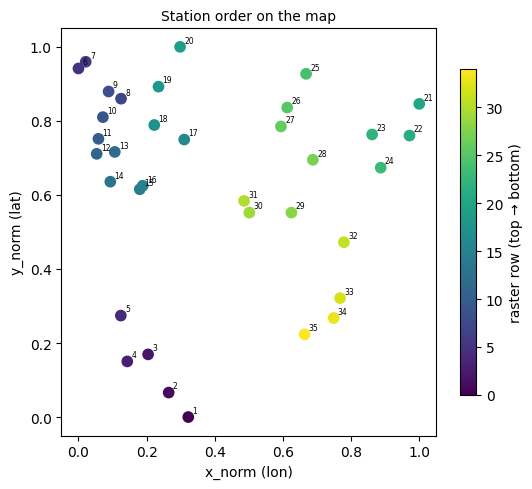

In [7]:
# Normalised coordinates are (near-)identical across seasons; use spring's.
params_xy = {c: per_season_params["spring"][c] for c in stations}
order = spatial_station_order(params_xy, stations)
plot_station_order_map(params_xy, stations, order=order);

## 1. Occurrence raster with spatially ordered stations

**Model simulated here: the original shared-$\lambda$ LMC** (Eq. (4) of main.tex, $\hat\theta_s=(\hat\lambda_s,\hat\sigma_{w^c,s},\hat\sigma_{w^{(0)},s},\hat\sigma_{w^{(1)},s})$ loaded from `theta_fit_spain_portugal_by_season.csv` above). The state-dependent-$\lambda^{(r)}$ counterpart follows in section 1.b.

Each station-day is coloured **wet** ($r_{n,j}=1$), **dry**, **heavy dry** (dry with running dry-spell age $\ge h = 10$ days, the age being censored at missing values and at the record start) or **missing**. Time runs top → bottom over the full 1980–2020 calendar (season strip and year labels on the left); the columns are the stations in the seriation order above, so spatially coherent episodes appear as *horizontally contiguous* patches.

**How to read it.** The simulated figure is one random replicate, not a reconstruction of the observed years — only the *texture* is comparable: typical width (spatial extent) and height (duration) of wet stripes and of dark-red drought patches, and how they vary across seasons. Observed patches wider/more coherent than simulated ones → fitted spatial dependence too weak; the converse → too strong.

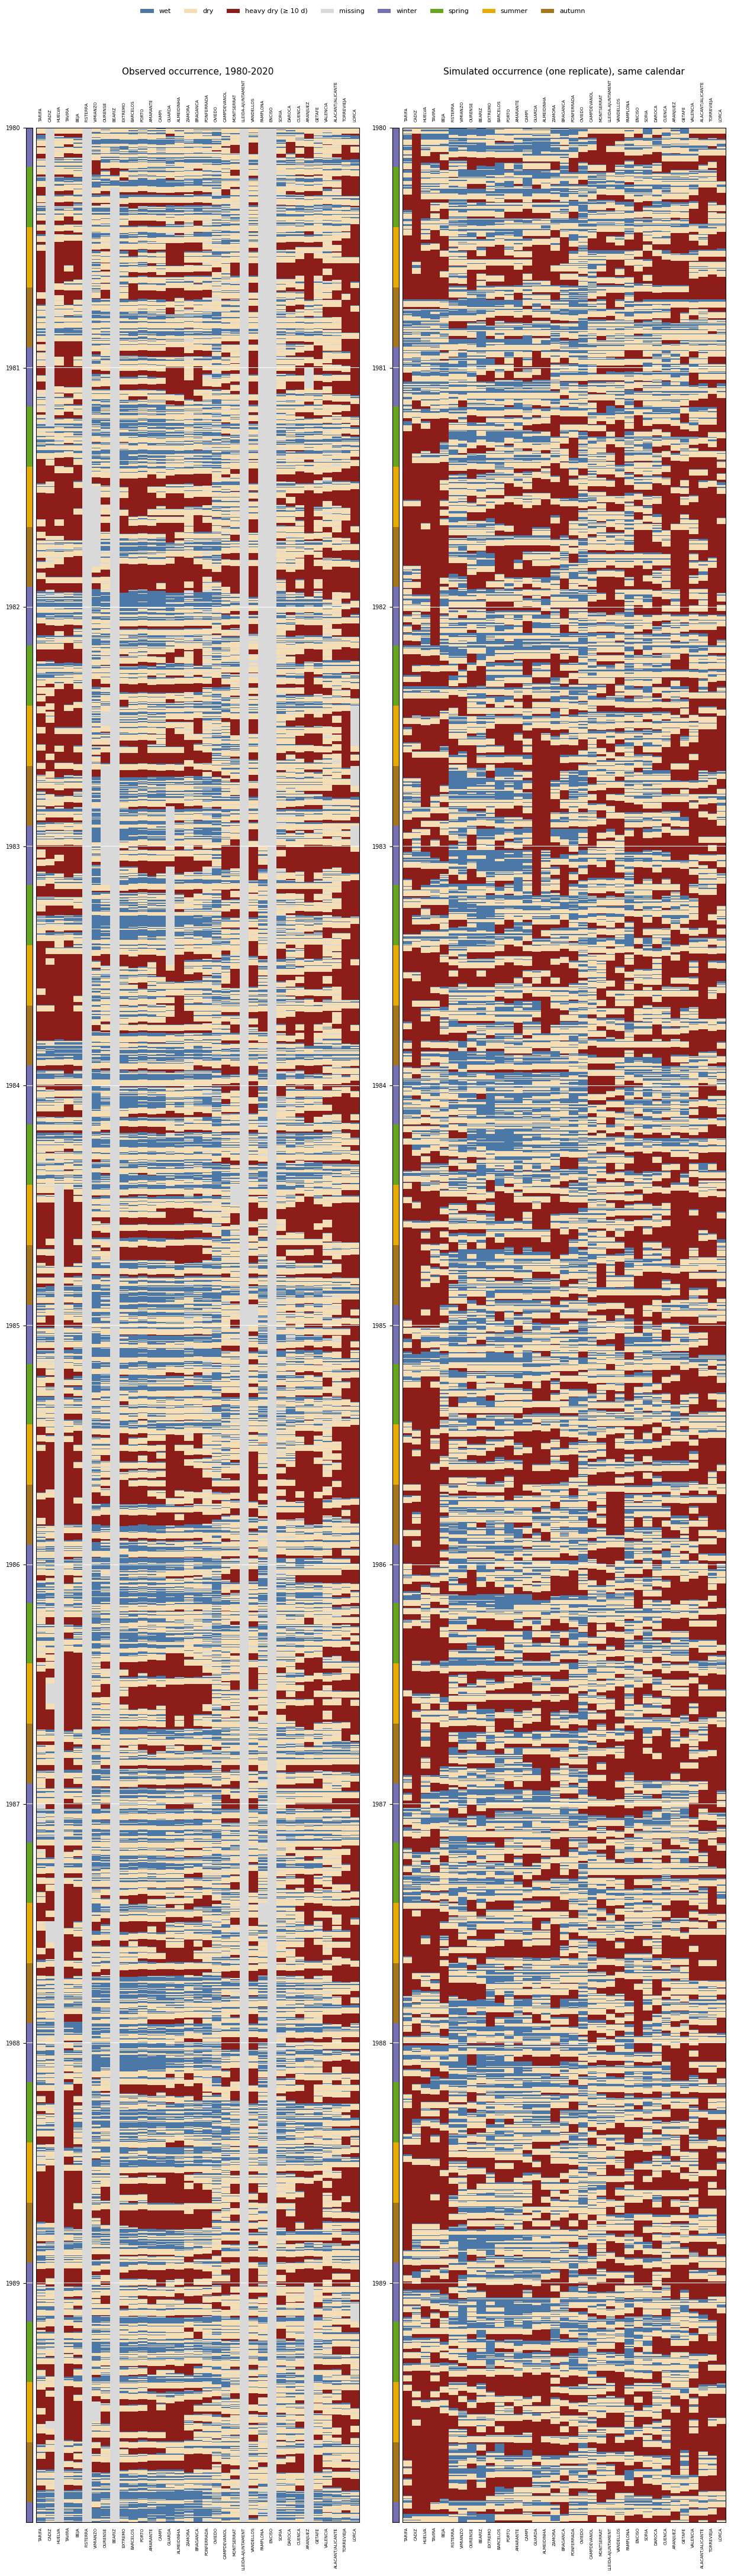

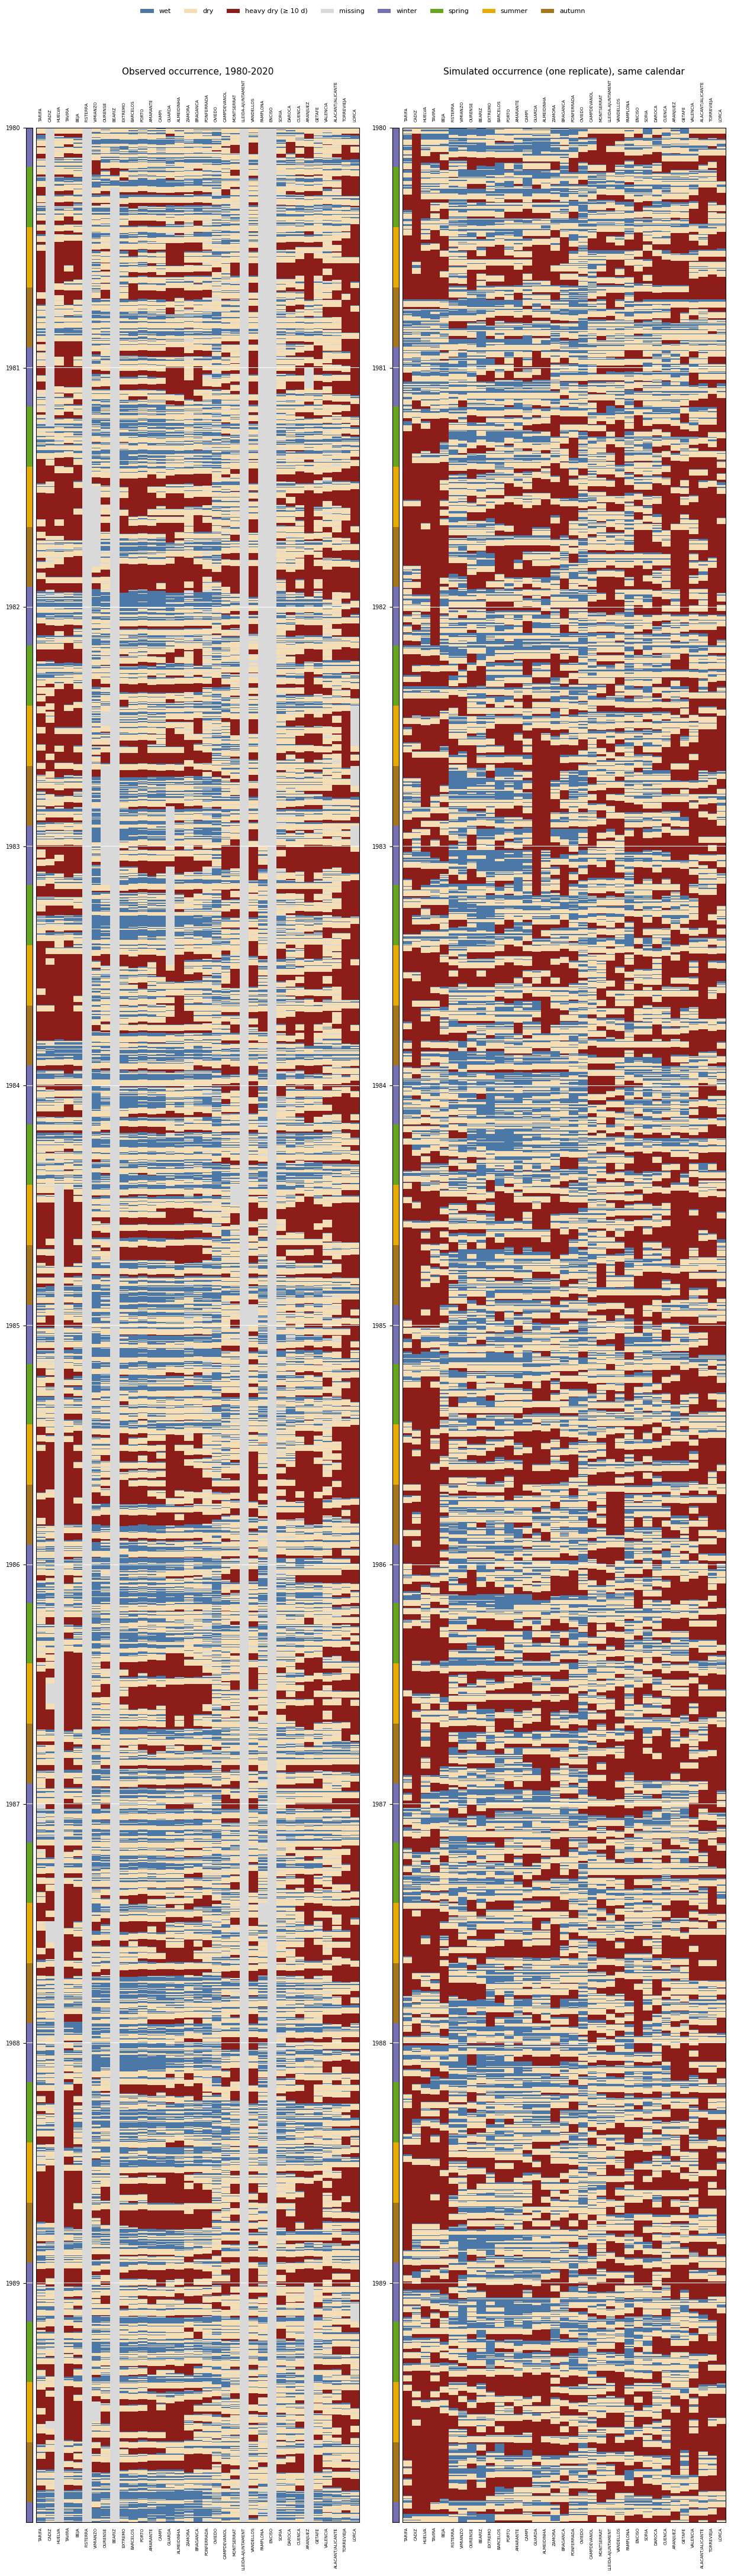

In [8]:
HEAVY_DRY_MIN_DAYS = 10

plot_occurrence_raster_time_rows_pair(
    Rbin_obs, Rbin_sim, params_xy, order=order,
    heavy_dry_min_days=HEAVY_DRY_MIN_DAYS,
    titles=("Observed occurrence, 1980-2020",
            "Simulated occurrence (one replicate), same calendar"),
    filename="diag_raster_time_rows_obs_vs_sim.pdf",
    station_width=0.15,
    time_window=("1980", "1989"),
    figsize=(24, 44),
)

## 1.b Occurrence raster — alternative model with state-dependent $\lambda^{(r)}$

**Model simulated here: the alternative suggestion of main.tex (blue)** — state-dependent weights $\lambda^{(0)}$ (dry field) / $\lambda^{(1)}$ (wet field), $\hat\theta_s=(\hat\lambda^{(0)}_s,\hat\lambda^{(1)}_s,\hat\sigma_{w^c,s},\hat\sigma_{w^{(0)},s},\hat\sigma_{w^{(1)},s})$ loaded from the CSV saved by the state-dependent fit section of Part 1 (covariance blocks of Eq. (5'): same-state weight $\lambda^{(r)}$, dry-wet cross term $-\sqrt{\lambda^{(0)}\lambda^{(1)}}\,\rho_{w^{(c)}}$).

Same continuous multi-season simulation rule, same seed, same calendar, same seriation order and same reading grid as the shared-$\lambda$ raster above — the observed panel is identical, so any texture difference between the two simulated panels comes from letting the dry and wet fields carry different mixing weights.

In [ ]:
# Fitted state-dependent-lambda theta per season, saved by the fit section of Part 1.
RESULTS_PATH_SD = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs" / "theta_fit_spain_portugal_by_season_state_dep_lambda.csv"
if not RESULTS_PATH_SD.exists():
    raise FileNotFoundError(
        f"{RESULTS_PATH_SD} not found: run the state-dependent 'Fit theta per season' "
        "section above once to create it."
    )
df_theta_sd = pd.read_csv(RESULTS_PATH_SD, index_col="season")
# A 5-tuple selects the state-dependent variant in simulate_cholesky_seasonal.
theta_by_season_sd = {
    s: (r["lam0"], r["lam1"], r["sigma_wc"], r["sigma_w0"], r["sigma_w1"])
    for s, r in df_theta_sd.iterrows()
}
print(df_theta_sd[["lam0", "lam1", "sigma_wc", "sigma_w0", "sigma_w1"]].round(4).to_string())

# One simulated replicate on the same calendar and with the same seed as the
# shared-lambda raster above.
sim_hist_sd = simulate_cholesky_seasonal(
    Rbin_obs.index, theta_by_season_sd, per_season_params,
    station_names=stations, n_burn=1000, seed=0,
)
Rbin_sim_sd = history_to_Rbin(sim_hist_sd)

plot_occurrence_raster_time_rows_pair(
    Rbin_obs, Rbin_sim_sd, params_xy, order=order,
    heavy_dry_min_days=HEAVY_DRY_MIN_DAYS,
    titles=("Observed occurrence, 1980-2020",
            "Simulated occurrence, state-dependent-$\\lambda^{(r)}$ model (one replicate)"),
    filename="diag_raster_time_rows_obs_vs_sim_state_dep_lambda.pdf",
    station_width=0.15,
    time_window=("1980", "1989"),
    figsize=(24, 44),
)